In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("../data/churn-bigml.csv")
df_cluster = df.drop('Churn', axis=1)
df_cluster = pd.get_dummies(df_cluster, drop_first=True)
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)


In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.03382483 0.03259465]


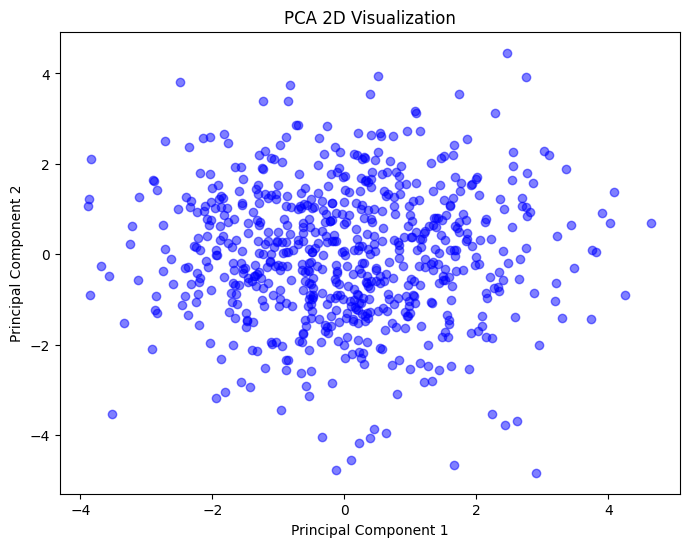

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c='blue', alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")
plt.show()


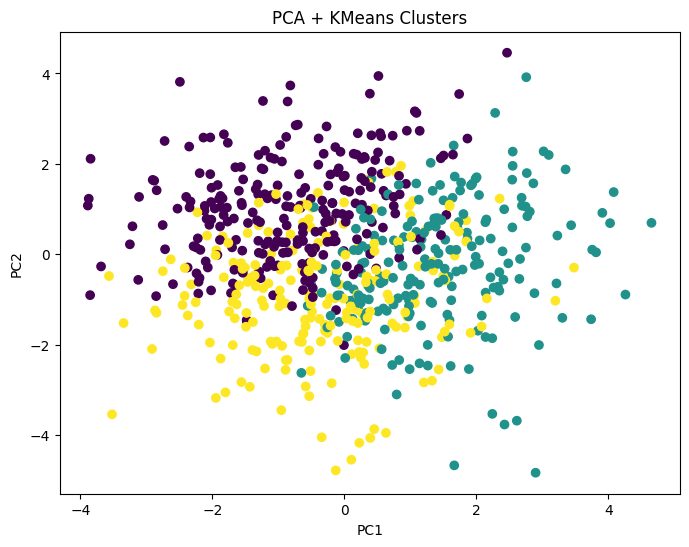

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("PCA + KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


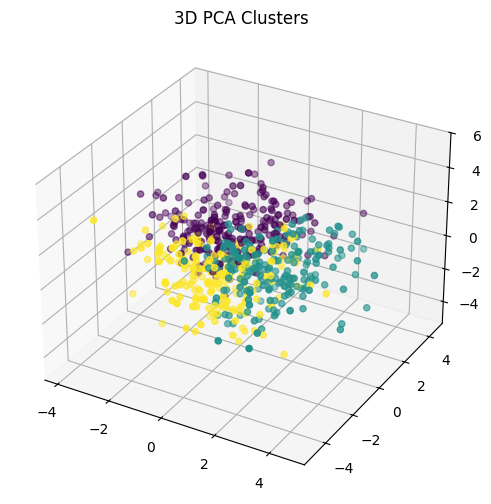

In [6]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=labels, cmap='viridis')
ax.set_title("3D PCA Clusters")
plt.show()


In [7]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)


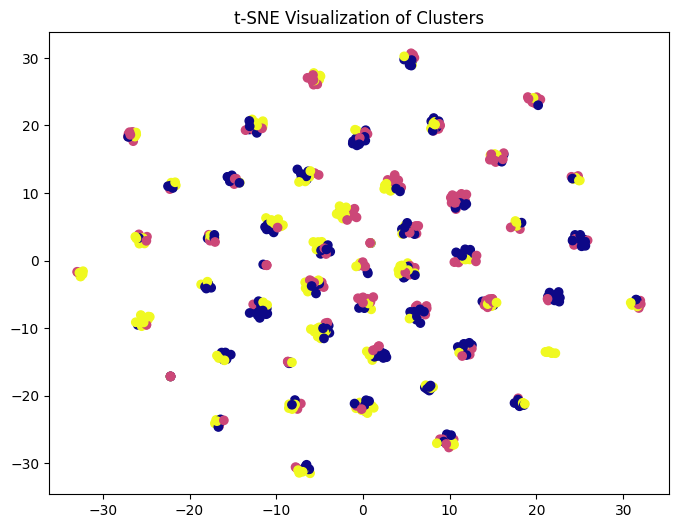

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap='plasma')
plt.title("t-SNE Visualization of Clusters")
plt.show()


In [6]:
import pandas as pd
import umap
df=pd.read_csv("../data/churn-bigml.csv")
X=df.select_dtypes(include='number')
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)
print(X_umap.shape)

(667, 2)
